# 12 - EDA: Análisis Exploratorio de `data/processed`

Frames extraídos de los videos de la granja en el paso `11_procesarimagenes.ipynb`.
Cada video se descomponió en imágenes JPG tomadas **cada 20 segundos**.

### Estructura del dataset

Las carpetas de video cuelgan directamente de `data/processed` (ya no hay un nivel intermedio
`frames/`):

```
data/processed/
├── 20260728_085142_tp00014/                  <- carpeta = 1 video
│   ├── 20260728_085142_tp00014_t0000s_1.jpg  <- segundo 0,   frame #1
│   ├── 20260728_085142_tp00014_t0020s_2.jpg  <- segundo 20,  frame #2
│   └── ...
└── ...
```

El nombre de la carpeta (y del archivo) tiene el formato `AAAAMMDD_HHMMSS_tpXXXXX`:

- **fecha** y **hora** de inicio de la grabación
- **tpXXXXX** = identificador de la cámara (global, no se reinicia por fecha)
- **segundo** = posición temporal dentro del video, múltiplo de 20


In [1]:
import math
import os
import re
from datetime import datetime
from pathlib import Path

os.chdir(r"B:\11RossyDocumentos\18ProyectoPollos\12Avances\11_proyecto_pollos")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from siuba import *

PROYECTO = Path.cwd()
RUTA_FRAMES = PROYECTO / "data" / "processed"
RUTA_ARTIFACTS = PROYECTO / "artifacts"
RUTA_ARTIFACTS.mkdir(exist_ok=True)

INTERVALO_SEGUNDOS = 20   # usado en 11_procesarimagenes.ipynb
CALCULAR_BRILLO = True   # lee las ~400 imagenes (~10 s)

assert RUTA_FRAMES.exists(), f"No existe: {RUTA_FRAMES}"
RUTA_FRAMES, len(list(RUTA_FRAMES.glob("*")))

(WindowsPath('B:/11RossyDocumentos/18ProyectoPollos/12Avances/11_proyecto_pollos/data/processed'),
 10)

In [2]:
%config InlineBackend.figure_format = 'png'
%config InlineBackend.print_figure_kwargs = {'dpi': 72, 'bbox_inches': 'tight'}
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

## 0. Funciones auxiliares

In [3]:
PATRON_VIDEO = re.compile(r"^(?P<fecha>\d{8})_(?P<hora>\d{6})_(?P<camara>tp\d+)$")
PATRON_FRAME = re.compile(r"_t(?P<segundo>\d+)s_(?P<orden>\d+)\.jpg$")

carpetas_video = sorted(p for p in RUTA_FRAMES.iterdir() if p.is_dir())
archivos_sueltos = sorted(p for p in RUTA_FRAMES.iterdir() if p.is_file())


def titulo_de_video(video):
    """Convierte el nombre de la carpeta en un titulo legible."""
    m = PATRON_VIDEO.match(video)
    if not m:
        return video
    fecha = datetime.strptime(m["fecha"], "%Y%m%d").date()
    hora = m["hora"]
    return f"{fecha:%d/%m/%Y}  {hora[:2]}:{hora[2:4]}:{hora[4:]}  cam {m['camara']}"


def leer_rgb(ruta):
    """Lee una imagen con OpenCV y la devuelve en RGB (OpenCV entrega BGR)."""
    img = cv2.imread(str(ruta))
    if img is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def mostrar_una(ruta, ancho=7):
    """Muestra una unica imagen, escalada para no saturar la pantalla."""
    img = leer_rgb(ruta)
    fig, ax = plt.subplots(figsize=(ancho, ancho * img.shape[0] / img.shape[1]))
    ax.imshow(img)
    ax.set_title(Path(ruta).name, fontsize=9)
    ax.axis("off")
    fig.tight_layout()
    plt.show()


def mostrar(rutas, titulos=None, ncols=3, ancho=3.5):
    """Muestra una rejilla de imagenes."""
    rutas = [Path(r) for r in rutas]
    if not rutas:
        print("No hay imagenes para mostrar.")
        return
    if titulos is None:
        titulos = [r.name for r in rutas]
    ncols = max(1, min(ncols, len(rutas)))
    nrows = math.ceil(len(rutas) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * ancho, nrows * ancho * 9 / 16))
    axes = np.atleast_1d(axes).ravel()
    for ax, ruta, titulo in zip(axes, rutas, titulos):
        ax.imshow(leer_rgb(ruta))
        ax.set_title(titulo, fontsize=8)
        ax.axis("off")
    for ax in axes[len(rutas):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()


print(f"Carpetas de video: {len(carpetas_video)}")
print(f"Archivos sueltos : {[p.name for p in archivos_sueltos]}")

Carpetas de video: 10
Archivos sueltos : []


## 1. Inventario del dataset

In [4]:
inventario = pd.DataFrame(
    {
        "carpeta": [p.name for p in carpetas_video],
        "descripcion": [titulo_de_video(p.name) for p in carpetas_video],
        "n_imagenes": [len(list(p.glob("*.jpg"))) for p in carpetas_video],
        "mb": [sum(f.stat().st_size for f in p.glob("*.jpg")) / 1024**2 for p in carpetas_video],
    }
)
inventario["mb"] = inventario["mb"].round(1)
inventario

,carpeta,descripcion,n_imagenes,mb
0,20240805_215845_tp00007,05/08/2024 21:58:45 cam tp00007,63,37.7
1,20240805_215845_tp00015,05/08/2024 21:58:45 cam tp00015,63,45.3
2,20260727_173621_tp00000,27/07/2026 17:36:21 cam tp00000,63,35.0
3,20260728_064628_tp00008,28/07/2026 06:46:28 cam tp00008,63,36.8
4,20260728_070720_tp00009,28/07/2026 07:07:20 cam tp00009,63,36.6
5,20260728_072812_tp00010,28/07/2026 07:28:12 cam tp00010,63,41.0
6,20260728_074904_tp00011,28/07/2026 07:49:04 cam tp00011,63,40.7
7,20260728_080956_tp00012,28/07/2026 08:09:56 cam tp00012,63,44.3
8,20260728_083048_tp00013,28/07/2026 08:30:48 cam tp00013,63,46.4
9,20260728_085142_tp00014,28/07/2026 08:51:42 cam tp00014,43,31.5


In [5]:
total_img = int(inventario["n_imagenes"].sum())
total_mb = float(inventario["mb"].sum())

print(f"Videos (carpetas)  : {len(inventario)}")
print(f"Imagenes totales   : {total_img}")
print(f"Tamano total       : {total_mb:,.1f} MB")
print(f"Promedio por imagen : {total_mb * 1024 / total_img:,.0f} KB")
print(f"Frames por video   : min={inventario['n_imagenes'].min()}  max={inventario['n_imagenes'].max()}")
print(f"Archivos sueltos   : {[p.name for p in archivos_sueltos] or 'ninguno'}")

Videos (carpetas)  : 10
Imagenes totales   : 610
Tamano total       : 395.3 MB
Promedio por imagen : 664 KB
Frames por video   : min=43  max=63
Archivos sueltos   : ninguno


> **Nota:** `data/processed` es ya la ruta raíz del dataset de frames, cuelga de ella
> directamente una carpeta por video. El inventario se arma **solo con directorios**
> (`p.is_dir()`), de modo que cualquier archivo suelto que se deje en esta ruta (un `.zip`, un
> `.csv`, etc.) queda fuera del análisis en lugar de romperlo.

## 2. Indice de metadatos de cada imagen

Construimos un DataFrame con **una fila por imagen**. Este es el punto de partida de cualquier
analisis posterior (etiquetado, deteccion, balanceo por fecha, etc.).

In [6]:
registros = []

for carpeta in carpetas_video:
    m = PATRON_VIDEO.match(carpeta.name)
    if not m:
        print("[!] carpeta con nombre no reconocido:", carpeta.name)
        continue

    fecha = datetime.strptime(m["fecha"], "%Y%m%d")
    hora = datetime.strptime(m["hora"], "%H%M%S")

    for archivo in sorted(carpeta.glob("*.jpg")):
        mf = PATRON_FRAME.search(archivo.name)
        if not mf:
            print("[!] archivo con nombre no reconocido:", archivo.name)
            continue

        registros.append(
            {
                "video": carpeta.name,
                "camara": m["camara"],
                "fecha": fecha.date(),
                "hora_inicio": hora.time(),
                "segundo": int(mf["segundo"]),
                "orden": int(mf["orden"]),
                "archivo": archivo.name,
                "ruta": archivo.relative_to(PROYECTO).as_posix(),
                "bytes": archivo.stat().st_size,
            }
        )

indice = pd.DataFrame(registros).sort_values(["video", "segundo"]).reset_index(drop=True)
indice.head(8)

,video,camara,fecha,hora_inicio,segundo,orden,archivo,ruta,bytes
0,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,0,1,20240805_215845_tp00007_t0000s_1.jpg,data/processed/20240805_215845_tp00007/2024080...,621109
1,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,20,2,20240805_215845_tp00007_t0020s_2.jpg,data/processed/20240805_215845_tp00007/2024080...,239430
2,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,40,3,20240805_215845_tp00007_t0040s_3.jpg,data/processed/20240805_215845_tp00007/2024080...,622668
3,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,60,4,20240805_215845_tp00007_t0060s_4.jpg,data/processed/20240805_215845_tp00007/2024080...,630942
4,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,80,5,20240805_215845_tp00007_t0080s_5.jpg,data/processed/20240805_215845_tp00007/2024080...,647417
5,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,100,6,20240805_215845_tp00007_t0100s_6.jpg,data/processed/20240805_215845_tp00007/2024080...,621779
6,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,120,7,20240805_215845_tp00007_t0120s_7.jpg,data/processed/20240805_215845_tp00007/2024080...,653035
7,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,140,8,20240805_215845_tp00007_t0140s_8.jpg,data/processed/20240805_215845_tp00007/2024080...,653984


In [7]:
indice.shape, indice.dtypes.to_frame("tipo")

((610, 9),
                tipo
 video        object
 camara       object
 fecha        object
 hora_inicio  object
 segundo       int64
 orden         int64
 archivo      object
 ruta         object
 bytes         int64)

## 3. ¿Cuántas fechas hay?

In [8]:
fechas = sorted(indice["fecha"].unique())
print(f"Cantidad de fechas distintas: {len(fechas)}\n")
for f in fechas:
    sub = indice[indice["fecha"] == f]
    print(f"  {f:%Y-%m-%d}   videos={sub['video'].nunique():2d}   imagenes={len(sub):3d}")

print(f"\nPrimer dia: {fechas[0]}   |   Ultimo dia: {fechas[-1]}")
print(f"Dias entre el primero y el ultimo: {(fechas[-1] - fechas[0]).days:,}")

Cantidad de fechas distintas: 3

  2024-08-05   videos= 2   imagenes=126
  2026-07-27   videos= 1   imagenes= 63
  2026-07-28   videos= 7   imagenes=421

Primer dia: 2024-08-05   |   Ultimo dia: 2026-07-28
Dias entre el primero y el ultimo: 722


In [9]:
por_fecha = (
    indice.groupby("fecha")
    .agg(
        videos=("video", "nunique"),
        camaras=("camara", "nunique"),
        imagenes=("video", "size"),
        mb=("bytes", lambda s: s.sum() / 1024**2),
    )
    .round(1)
    .reset_index()
    .sort_values("fecha")
)
por_fecha["img_por_video"] = (por_fecha["imagenes"] / por_fecha["videos"]).round(1)
por_fecha["pct_total"] = (100 * por_fecha["imagenes"] / por_fecha["imagenes"].sum()).round(1)
por_fecha

,fecha,videos,camaras,imagenes,mb,img_por_video,pct_total
0,2024-08-05,2,2,126,83.0,63.0,20.7
1,2026-07-27,1,1,63,35.0,63.0,10.3
2,2026-07-28,7,7,421,277.2,60.1,69.0


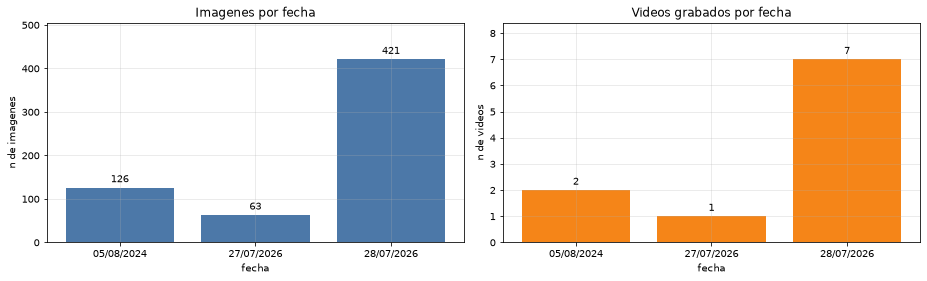

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

etiquetas = [f"{f:%d/%m/%Y}" for f in por_fecha["fecha"]]

barras = ax1.bar(etiquetas, por_fecha["imagenes"], color="#4C78A8")
ax1.bar_label(barras, padding=3)
ax1.set_title("Imagenes por fecha")
ax1.set_xlabel("fecha")
ax1.set_ylabel("n de imagenes")
ax1.set_ylim(0, por_fecha["imagenes"].max() * 1.20)

barras = ax2.bar(etiquetas, por_fecha["videos"], color="#F58518")
ax2.bar_label(barras, padding=3)
ax2.set_title("Videos grabados por fecha")
ax2.set_xlabel("fecha")
ax2.set_ylabel("n de videos")
ax2.set_ylim(0, por_fecha["videos"].max() * 1.20)

fig.tight_layout()
plt.show()


### 3.1 Composicion: que videos aporta cada fecha

In [11]:
matriz = indice.pivot_table(
    index="fecha", columns="video", values="archivo", aggfunc="size", fill_value=0
)
matriz

video,20240805_215845_tp00007,20240805_215845_tp00015,20260727_173621_tp00000,20260728_064628_tp00008,20260728_070720_tp00009,20260728_072812_tp00010,20260728_074904_tp00011,20260728_080956_tp00012,20260728_083048_tp00013,20260728_085142_tp00014
fecha,,,,,,,,,,
2024-08-05,63,63,0,0,0,0,0,0,0,0
2026-07-27,0,0,63,0,0,0,0,0,0,0
2026-07-28,0,0,0,63,63,63,63,63,63,43


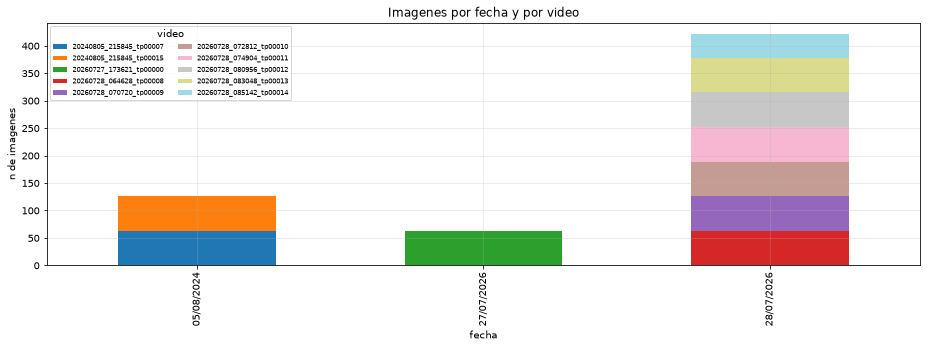

In [12]:
ax = matriz.plot(
    kind="bar", stacked=True, figsize=(13, 5), colormap="tab20", width=0.55, legend=True
)
ax.set_title("Imagenes por fecha y por video")
ax.set_xlabel("fecha")
ax.set_ylabel("n de imagenes")
ax.set_xticks(range(len(matriz.index)))
ax.set_xticklabels([f"{f:%d/%m/%Y}" for f in matriz.index])
ax.legend(title="video", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


## 4. Muestra de imagenes

video   : 20240805_215845_tp00007
camara  : tp00007
fecha   : 2024-08-05  21:58:45
segundo : 0 s  (frame 1 del video)
ruta    : data/processed/20240805_215845_tp00007/20240805_215845_tp00007_t0000s_1.jpg


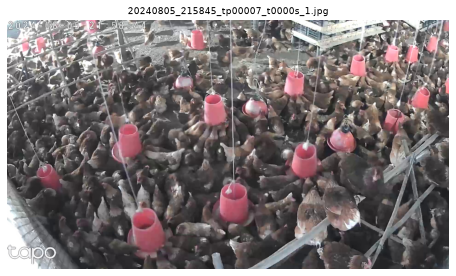

In [13]:
N = 0  # indice dentro del indice de metadatos
fila = indice.loc[N]
print(f"video   : {fila['video']}")
print(f"camara  : {fila['camara']}")
print(f"fecha   : {fila['fecha']:%Y-%m-%d}  {fila['hora_inicio']}")
print(f"segundo : {int(fila['segundo'])} s  (frame {int(fila['orden'])} del video)")
print(f"ruta    : {fila['ruta']}")

mostrar_una(PROYECTO / fila["ruta"])

### 4.1 Una imagen por video (frame intermedio de cada grabacion)

In [14]:
central = (
    indice.sort_values("segundo")
    .groupby("video", group_keys=False)
    .apply(lambda g: g.iloc[len(g) // 2], include_groups=False)
    .sort_values(["fecha", "video"])
    .reset_index()
)
central[["video", "camara", "fecha", "segundo", "archivo"]]

,video,camara,fecha,segundo,archivo
0,20240805_215845_tp00007,tp00007,2024-08-05,620,20240805_215845_tp00007_t0620s_32.jpg
1,20240805_215845_tp00015,tp00015,2024-08-05,620,20240805_215845_tp00015_t0620s_32.jpg
2,20260727_173621_tp00000,tp00000,2026-07-27,620,20260727_173621_tp00000_t0620s_32.jpg
3,20260728_064628_tp00008,tp00008,2026-07-28,620,20260728_064628_tp00008_t0620s_32.jpg
4,20260728_070720_tp00009,tp00009,2026-07-28,620,20260728_070720_tp00009_t0620s_32.jpg
5,20260728_072812_tp00010,tp00010,2026-07-28,620,20260728_072812_tp00010_t0620s_32.jpg
6,20260728_074904_tp00011,tp00011,2026-07-28,620,20260728_074904_tp00011_t0620s_32.jpg
7,20260728_080956_tp00012,tp00012,2026-07-28,620,20260728_080956_tp00012_t0620s_32.jpg
8,20260728_083048_tp00013,tp00013,2026-07-28,620,20260728_083048_tp00013_t0620s_32.jpg
9,20260728_085142_tp00014,tp00014,2026-07-28,420,20260728_085142_tp00014_t0420s_22.jpg


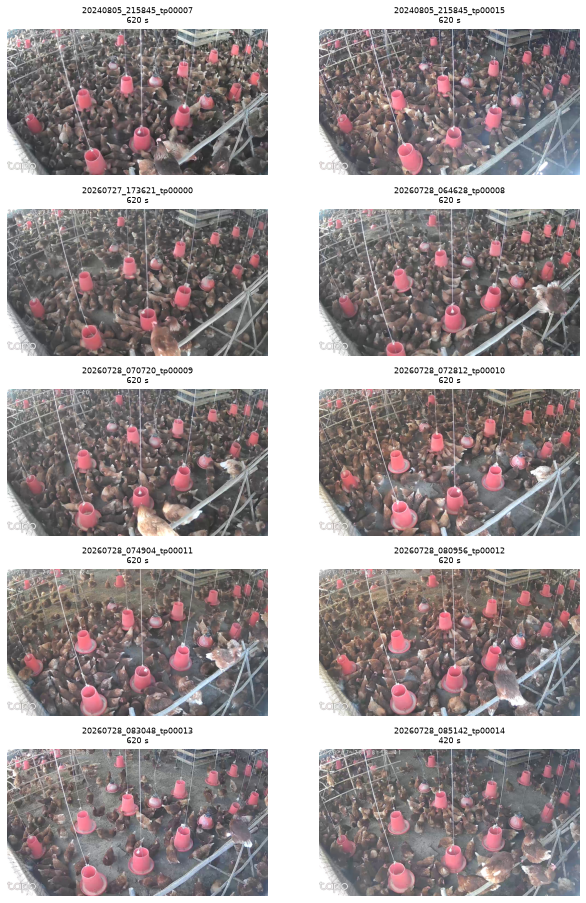

In [15]:
mostrar(
    [PROYECTO / r for r in central["ruta"]],
    titulos=[f"{v}\n{int(s)} s" for v, s in zip(central["video"], central["segundo"])],
    ncols=2, ancho=4.5,
)

### 4.2 Evolucion dentro de un mismo video (inicio / medio / final)

Cambia `VIDEO_EJEMPLO` por `indice['video'].iloc[k]` para ver otro video.

20240805_215845_tp00007  ->  63 frames, 0-1240 s


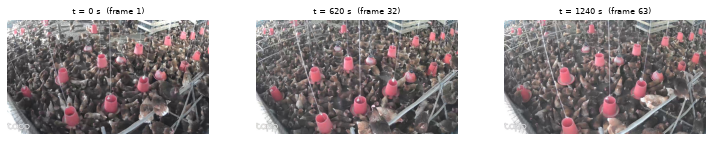

In [16]:
VIDEO_EJEMPLO = indice["video"].iloc[0]
trama = indice[indice["video"] == VIDEO_EJEMPLO].sort_values("segundo").reset_index(drop=True)
print(f"{VIDEO_EJEMPLO}  ->  {len(trama)} frames, 0-{int(trama['segundo'].max())} s")

posiciones = [0, len(trama) // 2, len(trama) - 1]
mostrar(
    [PROYECTO / r for r in trama.loc[posiciones, "ruta"]],
    titulos=[f"t = {int(trama.loc[p, 'segundo'])} s  (frame {int(trama.loc[p, 'orden'])})" for p in posiciones],
    ncols=3,
)

### 4.3 Una imagen por fecha

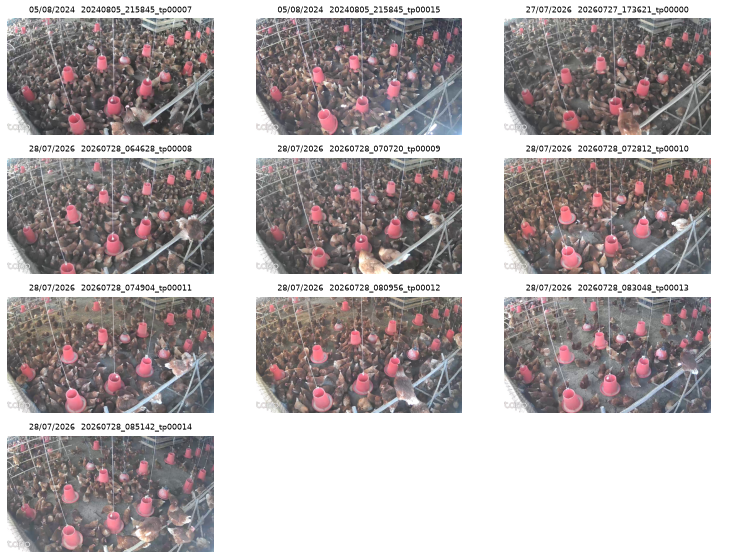

In [17]:
por_fecha_fila = (
    indice.sort_values("segundo")
    .groupby(["fecha", "video"], group_keys=False)
    .apply(lambda g: g.iloc[len(g) // 2], include_groups=False)
    .reset_index()
    .sort_values(["fecha", "video"])
)
mostrar(
    [PROYECTO / r for r in por_fecha_fila["ruta"]],
    titulos=[f"{f:%d/%m/%Y}  {v}" for f, v in zip(por_fecha_fila["fecha"], por_fecha_fila["video"])],
    ncols=3,
)

## 5. Cobertura temporal y muestreo cada 20 s

In [18]:
ordenado = indice.sort_values(["video", "segundo"]).copy()
ordenado["gap_s"] = ordenado.groupby("video")["segundo"].diff()

gaps = ordenado["gap_s"].dropna()
print("Intervalos (s) entre frames muestreados consecutivos:")
print(gaps.value_counts().sort_index().to_string())

print(f"Todos los gaps == {INTERVALO_SEGUNDOS} s     : {bool((gaps == INTERVALO_SEGUNDOS).all())}")
print(f"Duplicados (video, segundo)          : {indice.duplicated(['video', 'segundo']).sum()}")
print(f"Nombres de archivo duplicados        : {indice.duplicated(['archivo']).sum()}")
print(f"Orden correlativo con el nombre      : {bool((indice['orden'] == indice.groupby('video').cumcount() + 1).all())}")

Intervalos (s) entre frames muestreados consecutivos:
gap_s
20.0    600
Todos los gaps == 20 s     : True
Duplicados (video, segundo)          : 0
Nombres de archivo duplicados        : 0
Orden correlativo con el nombre      : True


In [19]:
cobertura = (
    indice.groupby("video")
    .agg(
        fecha=("fecha", "first"),
        camara=("camara", "first"),
        inicio_s=("segundo", "min"),
        fin_s=("segundo", "max"),
        n_frames=("segundo", "size"),
    )
    .reset_index()
)
cobertura["duracion_min"] = ((cobertura["fin_s"] - cobertura["inicio_s"]) / 60).round(2)

# frames que le tocarian a cada video segun su propio rango de tiempo
cobertura["esperados_rango"] = cobertura["fin_s"] // INTERVALO_SEGUNDOS + 1

# referencia: cuantos frames tiene un video completo en este dataset (la moda)
N_TIPICO = int(cobertura["n_frames"].mode().iloc[0])
cobertura["faltantes"] = (N_TIPICO - cobertura["n_frames"]).clip(lower=0)
cobertura["completo"] = cobertura["n_frames"] >= N_TIPICO

print(f"Frames por video completo (moda): {N_TIPICO}")
cobertura.sort_values(["fecha", "video"]).drop(columns="completo")

Frames por video completo (moda): 63


,video,fecha,camara,inicio_s,fin_s,n_frames,duracion_min,esperados_rango,faltantes
0,20240805_215845_tp00007,2024-08-05,tp00007,0,1240,63,20.67,63,0
1,20240805_215845_tp00015,2024-08-05,tp00015,0,1240,63,20.67,63,0
2,20260727_173621_tp00000,2026-07-27,tp00000,0,1240,63,20.67,63,0
3,20260728_064628_tp00008,2026-07-28,tp00008,0,1240,63,20.67,63,0
4,20260728_070720_tp00009,2026-07-28,tp00009,0,1240,63,20.67,63,0
5,20260728_072812_tp00010,2026-07-28,tp00010,0,1240,63,20.67,63,0
6,20260728_074904_tp00011,2026-07-28,tp00011,0,1240,63,20.67,63,0
7,20260728_080956_tp00012,2026-07-28,tp00012,0,1240,63,20.67,63,0
8,20260728_083048_tp00013,2026-07-28,tp00013,0,1240,63,20.67,63,0
9,20260728_085142_tp00014,2026-07-28,tp00014,0,840,43,14.00,43,20


In [20]:
print("Cobertura total del dataset")
print(f"  frames            : {int(cobertura['n_frames'].sum())}")
print(f"  minutos grabados  : {cobertura['duracion_min'].sum():.1f}  ({cobertura['duracion_min'].sum() / 60:.2f} h)")
print(f"  rango de fechas   : {cobertura['fecha'].min():%Y-%m-%d}  ->  {cobertura['fecha'].max():%Y-%m-%d}")
print(f"  frames por video  : {N_TIPICO} en los videos completos")

incompletos = cobertura.loc[~cobertura["completo"], ["video", "n_frames", "faltantes"]]
print(f"\nVideos con menos frames de lo tipico: {len(incompletos)}")
print(incompletos.to_string(index=False) if len(incompletos) else "  (ninguno)")

Cobertura total del dataset
  frames            : 610
  minutos grabados  : 200.0  (3.33 h)
  rango de fechas   : 2024-08-05  ->  2026-07-28
  frames por video  : 63 en los videos completos

Videos con menos frames de lo tipico: 1
                  video  n_frames  faltantes
20260728_085142_tp00014        43         20


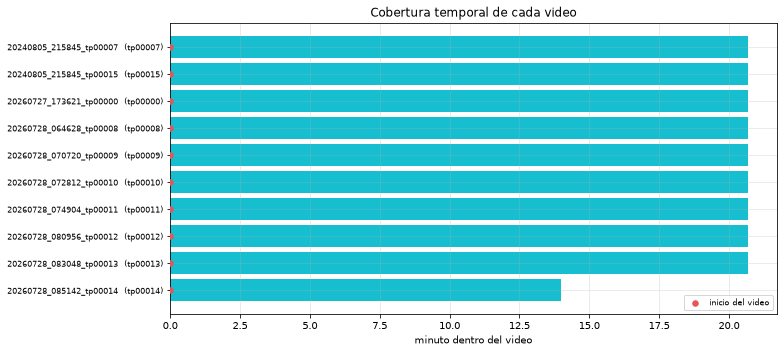

In [21]:
cov = cobertura.sort_values(["fecha", "video"])
y = np.arange(len(cov))

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(
    y,
    cov["duracion_min"],
    left=cov["inicio_s"] / 60,
    color=plt.get_cmap("tab10")([10, 12, 13, 14, 15, 16, 17, 18, 19, 20][: len(cov)]),
)
ax.scatter(cov["inicio_s"] / 60, y, s=30, color="#E45756", zorder=3, label="inicio del video")
ax.set_yticks(y)
ax.set_yticklabels([f"{v}  ({c})" for v, c in zip(cov["video"], cov["camara"])], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("minuto dentro del video")
ax.set_title("Cobertura temporal de cada video")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 6. Propiedades tecnicas de las imagenes

In [22]:
if CALCULAR_BRILLO:
    medidas = []
    for ruta in indice["ruta"]:
        gris = cv2.imread(str(PROYECTO / ruta), cv2.IMREAD_GRAYSCALE)
        if gris is None:
            continue
        medidas.append(
            {
                "archivo": Path(ruta).name,
                "ancho": int(gris.shape[1]),
                "alto": int(gris.shape[0]),
                "brillo": round(float(gris.mean()), 2),
                "contraste": round(float(gris.std()), 2),
            }
        )
    indice = indice.merge(pd.DataFrame(medidas), on="archivo", how="left")
    indice["kib"] = (indice["bytes"] / 1024).round(0)

print(f"Imagenes leidas: {indice['brillo'].notna().sum()} de {len(indice)}")
indice[["kib", "brillo", "contraste"]].describe().round(2)

Imagenes leidas: 610 de 610


,kib,brillo,contraste
count,610.00,610.00,610.00
mean,663.39,118.40,44.44
std,74.86,5.10,2.66
min,234.00,95.90,32.65
25%,602.25,115.39,42.75
50%,656.00,118.97,44.25
75%,726.00,121.51,45.74
max,855.00,131.34,63.19


In [23]:
resoluciones = indice.groupby(["ancho", "alto"]).size().rename("n_imagenes").reset_index()
resoluciones["aspecto"] = (resoluciones["ancho"] / resoluciones["alto"]).round(3)
display(resoluciones)
print(f"\nResolucion unica en todo el dataset: {resoluciones.shape[0] == 1}")

,ancho,alto,n_imagenes,aspecto
0,1920,1080,610,1.778



Resolucion unica en todo el dataset: True


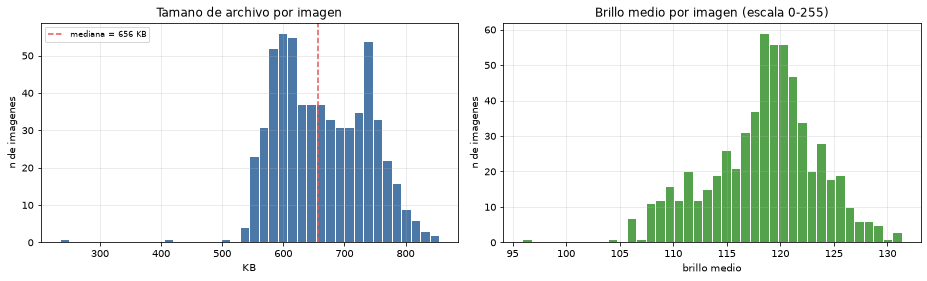

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(indice["kib"], bins=40, color="#4C78A8", edgecolor="white")
ax1.axvline(
    indice["kib"].median(), color="#E45756", linestyle="--", label=f"mediana = {indice['kib'].median():.0f} KB"
)
ax1.set_title("Tamano de archivo por imagen")
ax1.set_xlabel("KB")
ax1.set_ylabel("n de imagenes")
ax1.legend(fontsize=8)

ax2.hist(indice["brillo"], bins=40, color="#54A24B", edgecolor="white")
ax2.set_title("Brillo medio por imagen (escala 0-255)")
ax2.set_xlabel("brillo medio")
ax2.set_ylabel("n de imagenes")

fig.tight_layout()
plt.show()


## 7. Iluminacion a lo largo de la grabacion

Si el brillo cambia mucho dentro de un mismo video puede ser un problema de iluminacion
(luces que se encienden, apertura de cortinas) o de la escena (nieve, obstrucciones).

In [25]:
if CALCULAR_BRILLO:
    resumen_luz = (
        indice.groupby("video")
        .agg(
            brillo_prom=("brillo", "mean"),
            brillo_min=("brillo", "min"),
            brillo_max=("brillo", "max"),
            brillo_desv=("brillo", "std"),
            kb_prom=("kib", "mean"),
        )
        .round(2)
        .reset_index()
        .sort_values("video")
    )
    resumen_luz["rango_brillo"] = (resumen_luz["brillo_max"] - resumen_luz["brillo_min"]).round(2)
    display(resumen_luz)
else:
    print("CALCULAR_BRILLO = False: seccion omitida")

,video,brillo_prom,brillo_min,brillo_max,brillo_desv,kb_prom,rango_brillo
0,20240805_215845_tp00007,111.36,95.90,116.01,3.28,613.35,20.11
1,20240805_215845_tp00015,120.64,115.61,126.99,1.47,736.54,11.38
2,20260727_173621_tp00000,110.31,105.99,115.47,2.32,568.06,9.48
3,20260728_064628_tp00008,117.33,113.26,121.10,1.75,598.21,7.84
4,20260728_070720_tp00009,116.86,112.18,120.44,1.95,594.40,8.26
5,20260728_072812_tp00010,117.91,113.69,120.96,1.45,665.83,7.27
6,20260728_074904_tp00011,119.71,117.20,122.15,1.10,661.92,4.95
7,20260728_080956_tp00012,123.12,120.35,126.34,1.59,720.11,5.99
8,20260728_083048_tp00013,124.90,118.68,131.34,3.31,753.43,12.66
9,20260728_085142_tp00014,123.51,119.13,126.33,1.95,749.30,7.20


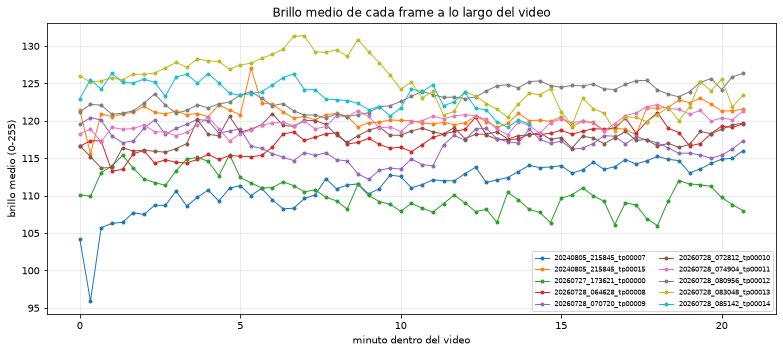

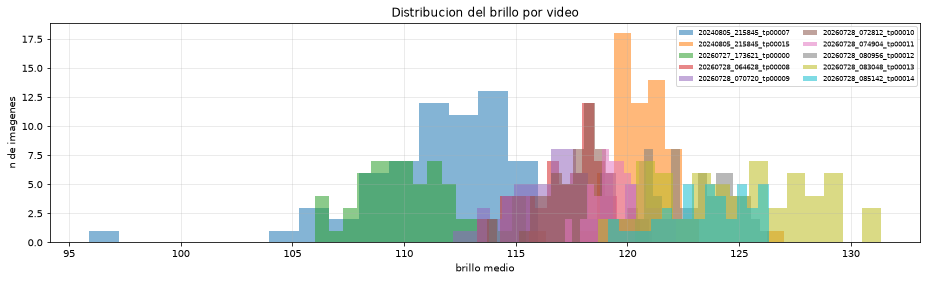

In [26]:
if CALCULAR_BRILLO:
    fig, ax = plt.subplots(figsize=(11, 5))
    for video, g in indice.sort_values("segundo").groupby("video"):
        ax.plot(g["segundo"] / 60, g["brillo"], marker="o", ms=3, lw=1, label=video)
    ax.set_xlabel("minuto dentro del video")
    ax.set_ylabel("brillo medio (0-255)")
    ax.set_title("Brillo medio de cada frame a lo largo del video")
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 4))
    colores = plt.get_cmap("tab10")
    for i, (video, g) in enumerate(indice.groupby("video")):
        ax.hist(g["brillo"], bins=15, alpha=0.55, color=colores(i % 10), label=video)
    ax.set_xlabel("brillo medio")
    ax.set_ylabel("n de imagenes")
    ax.set_title("Distribucion del brillo por video")
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    plt.show()


## 8. Fotogramas con exposicion atipica

### Por que hay que usar umbrales *relativos*

Un umbral absoluto no sirve aqui: lo que es "oscuro" en la camara `tp00007` (mediana 112) es
normal en `tp00012` (mediana 123). La forma correcta es comparar **cada fotograma contra la
mediana de su propio video**.

| Criterio | Definicion |
|---|---|
| `es_brillo_anomalo` | \|brillo / mediana(video) - 1\| > 10 % |
| `es_contraste_alto` | contraste / mediana(video) > 1.15 |
| `es_anomalo` | cualquiera de los dos |

Los umbrales son robustos: entre +-8 % y +-12 % de brillo, y entre 1.15x y 1.20x de contraste,
se marca **exactamente el mismo conjunto de fotogramas**.

In [27]:
# ---- deteccion de fotogramas con exposicion atipica (criterio relativo) ----
UMBRAL_BRILLO_REL = 0.10    # |brillo / mediana - 1| > 10 %
UMBRAL_CONTRASTE_REL = 1.15  # contraste / mediana > 1.15

med_brillo = indice.groupby("video")["brillo"].transform("median")
med_contraste = indice.groupby("video")["contraste"].transform("median")

indice["brillo_relativo"] = (indice["brillo"] / med_brillo).round(3)
indice["contraste_relativo"] = (indice["contraste"] / med_contraste).round(3)
indice["es_brillo_anomalo"] = (indice["brillo_relativo"] - 1).abs() > UMBRAL_BRILLO_REL
indice["es_contraste_alto"] = indice["contraste_relativo"] > UMBRAL_CONTRASTE_REL
indice["es_anomalo"] = indice["es_brillo_anomalo"] | indice["es_contraste_alto"]

print(f"Fotogramas con exposicion atipica: {int(indice['es_anomalo'].sum())} de {len(indice)}")
print(f"  detectados por brillo    : {int(indice['es_brillo_anomalo'].sum())}")
print(f"  detectados por contraste : {int(indice['es_contraste_alto'].sum())}")

anomalos = (
    indice[indice["es_anomalo"]]
    .sort_values(["fecha", "video", "segundo"])
    [["video", "fecha", "segundo", "archivo", "kib", "brillo", "contraste",
      "brillo_relativo", "contraste_relativo"]]
)
display(anomalos)

Fotogramas con exposicion atipica: 3 de 610
  detectados por brillo    : 1
  detectados por contraste : 3


,video,fecha,segundo,archivo,kib,brillo,contraste,brillo_relativo,contraste_relativo
1,20240805_215845_tp00007,2024-08-05,20,20240805_215845_tp00007_t0020s_2.jpg,234.0,95.90,63.19,0.856,1.303
64,20240805_215845_tp00015,2024-08-05,20,20240805_215845_tp00015_t0020s_2.jpg,409.0,115.61,56.49,0.959,1.232
126,20260727_173621_tp00000,2026-07-27,0,20260727_173621_tp00000_t0000s_1.jpg,630.0,110.13,56.32,1.001,1.337


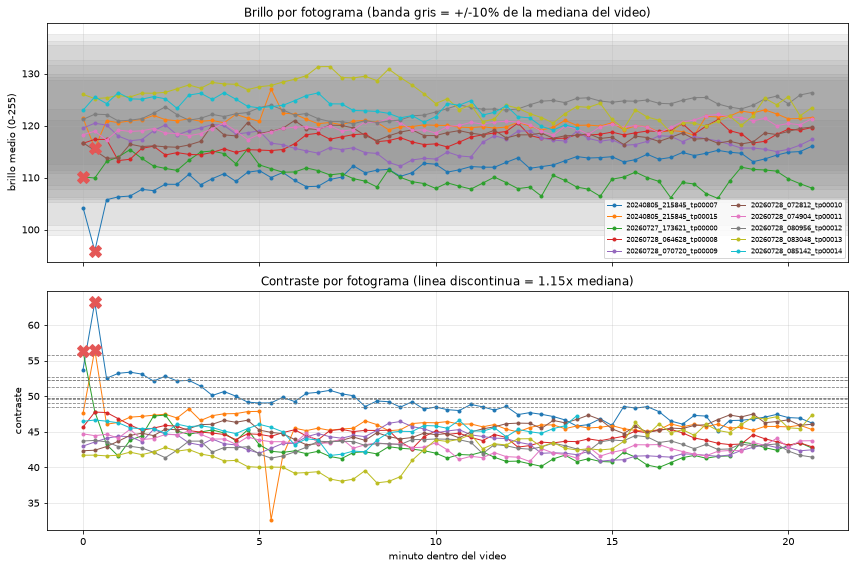

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for video, g in indice.sort_values("segundo").groupby("video"):
    ax1.plot(g["segundo"] / 60, g["brillo"], lw=1, marker="o", ms=3, label=video)
    med = g["brillo"].median()
    ax1.axhspan(med * (1 - UMBRAL_BRILLO_REL), med * (1 + UMBRAL_BRILLO_REL),
                color="grey", alpha=0.12, zorder=0)

    ax2.plot(g["segundo"] / 60, g["contraste"], lw=1, marker="o", ms=3, label=video)
    ax2.axhline(g["contraste"].median() * UMBRAL_CONTRASTE_REL,
                color="grey", ls="--", lw=0.8)

for _, r in anomalos.iterrows():
    ax1.plot(r["segundo"] / 60, r["brillo"], "X", color="#E45756", ms=12, zorder=5)
    ax2.plot(r["segundo"] / 60, r["contraste"], "X", color="#E45756", ms=12, zorder=5)

ax1.set_title(f"Brillo por fotograma (banda gris = +/-{UMBRAL_BRILLO_REL:.0%} de la mediana del video)")
ax1.set_ylabel("brillo medio (0-255)")
ax1.legend(fontsize=7, ncol=2)

ax2.set_title(f"Contraste por fotograma (linea discontinua = {UMBRAL_CONTRASTE_REL}x mediana)")
ax2.set_ylabel("contraste")
ax2.set_xlabel("minuto dentro del video")

fig.tight_layout()
plt.show()

## 9. Exportar el indice de metadatos

Para no recalcular todo cada vez que se abre el proyecto.

In [29]:
destino_indice = RUTA_ARTIFACTS / "eda_indice_frames.csv"
destino_resumen = RUTA_ARTIFACTS / "eda_resumen_por_fecha.csv"

indice.to_csv(destino_indice, index=False)
por_fecha.to_csv(destino_resumen, index=False)

print(f"{destino_indice.relative_to(PROYECTO)}  ({len(indice)} filas)")
print(f"{destino_resumen.relative_to(PROYECTO)}  ({len(por_fecha)} filas)")

indice.head(3)

artifacts\eda_indice_frames.csv  (610 filas)
artifacts\eda_resumen_por_fecha.csv  (3 filas)


,video,camara,fecha,hora_inicio,segundo,orden,archivo,ruta,bytes,ancho,alto,brillo,contraste,kib,brillo_relativo,contraste_relativo,es_brillo_anomalo,es_contraste_alto,es_anomalo
0,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,0,1,20240805_215845_tp00007_t0000s_1.jpg,data/processed/20240805_215845_tp00007/2024080...,621109,1920,1080,104.23,53.73,607.0,0.931,1.108,False,False,False
1,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,20,2,20240805_215845_tp00007_t0020s_2.jpg,data/processed/20240805_215845_tp00007/2024080...,239430,1920,1080,95.90,63.19,234.0,0.856,1.303,True,True,True
2,20240805_215845_tp00007,tp00007,2024-08-05,21:58:45,40,3,20240805_215845_tp00007_t0040s_3.jpg,data/processed/20240805_215845_tp00007/2024080...,622668,1920,1080,105.73,52.50,608.0,0.944,1.082,False,False,False


## Conclusiones

| Métrica | Valor |
|---|---|
| Ruta analizada | `data/processed` |
| Fechas distintas | 3 (2024-08-05, 2026-07-27, 2026-07-28) |
| Videos (carpetas) | 10 |
| Imágenes totales | 610 |
| Imágenes por video | 63 (salvo el video truncado: 43) |
| Intervalo de muestreo | **20 s**, sin huecos ni duplicados |
| Resolución | 1920 x 1080 (uniforme en las 610) |
| Tamaño por imagen | 234 - 855 KB (mediana 656 KB) |
| Tamaño total en disco | 395.3 MB |
| Cobertura total | 3.33 h de video (200.0 min) |
| Frames con exposición atípica | 3 (0.5 %) |

### Observaciones

1. **Desbalance fuerte de fechas**: 2026-07-28 aporta 421 imágenes (69 %), frente a 126 de
   2024-08-05 (20.7 %) y 63 de 2026-07-27 (10.3 %). Si el modelo entrena con esto queda muy
   sesgado hacia un solo día.
2. **Hueco temporal enorme** entre 2024-08-05 y 2026-07-27 (722 días). Son sesiones distintas,
   con distinta iluminación y posiblemente distinta configuración de la granja.
3. El video `20260728_085142_tp00014` está **incompleto** (43 frames de 63, 14.0 min frente a
   20.7 min): la grabación terminó antes. No es un fallo del pipeline.
4. Resolución **uniforme 1080p**: no hace falta redimensionar al leer, aunque para entrenar conviene
   (por ejemplo LetterBox a 640x640).
5. El **brillo medio varía más entre videos** (medianas de 110 a 125) que dentro de un mismo video
   (desviación de 1.1 a 3.3 niveles). La diferencia entre cámaras/sesiones domina sobre la
   variación temporal.
6. **Solo 3 fotogramas de 610 tienen exposición atípica**, pero 2 de ellos son el mismo evento:
   `tp00007` y `tp00015` se grabaron **simultáneamente** (2024-08-05 21:58:45) y ambos presentan
   su anomalía **exactamente en t = 20 s** (brillo -14.4 % y -4.1 %, contraste +30.3 % y +23.2 %,
   y entre 1.8x y 2.7x menos peso en disco). Que dos cámaras independientes coincidan en el mismo
   segundo confirma que fue un **evento real en la granja** (un foco encendido, una linterna, un
   cambio de iluminación), no corrupción de archivo. En `tp00007` los píxeles quemados (`>244`)
   suben de 2.7 % a 7.2 % y se concentran en la zona inferior derecha: el fotograma es más oscuro
   *y* tiene un foco quemado, o sea un descentrado de exposición, no un simple cambio de brillo.
7. El tercer anómalo (`20260727_173621_tp00000`, t = 0 s) lo detecta **solo el criterio de
   contraste** (+33.7 % con brillo normal): confirma que hacen falta las dos señales.
8. `data/processed` ya no tiene archivos sueltos (antes había un `.zip`); el inventario se construye
   solo con directorios, así que un archivo suelto futuro quedaría fuera del análisis.
